## Analyse the seed dataset
This notebook give some examples of how the structured tandem data can be analysed <br>
This analysis is based on the seed dataset, and it reproduces the figures and analysis presented in the paper    

In [181]:
import json
import os

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns

import holoviews as hv
from holoviews import dim, opts
# import plotly.graph_objects as go
# import plotly.express as pex
import bokeh as bk
import panel as pn

### Read in the seed tandem dataset

In [20]:
# Path to data
path_data_folder = os.path.join(os.getcwd(), "seed_dataset")
file_names = [file for file in os.listdir(path_data_folder) if os.path.isfile(os.path.join(path_data_folder, file))]
file_names = [file for file in file_names if file[-5:]==".json"]

# Read in data
data_files = []
for file in file_names:
    file_path = os.path.join(path_data_folder, file)
    with open(file_path, "r") as json_file:
        data_files.append(json.load(json_file))

# Flatten data and create dataframe
data = pd.json_normalize(data_files)
        
# Extract file index
file_index = [name.split('_')[-1].split('.')[0] for name in file_names]
file_index = [int(x) for x in file_index]

In [21]:
# Content in the first datafile
data_files[0]

{'data': {'m_def': 'perovskite_solar_cell_database.schema_packages.tandem.schema.PerovskiteTandemSolarCell',
  'reference': {'publication_date': '2021-03-18T00:00:00',
   'journal': 'Journal of Materials Chemistry A',
   'name_of_person_entering_the_data': 'Adam Hultqvist',
   'data_entered_by_author': False,
   'part_of_initial_dataset': True,
   'DOI_number': '10.1039/d0ta12286f',
   'publication_authors': ['Wu et al.'],
   'ID_temp': 0},
  'general': {'number_of_junctions': 2,
   'number_of_terminals': 2,
   'architecture': 'Monolithic',
   'flexible': False,
   'semitransparent': False,
   'encapsulated': False,
   'number_of_cells': 30,
   'photoabsorbers': ['OPV', 'Perovskite'],
   'photoabsorbers_string': 'OPV-Perovskite',
   'photoabsorbers_bandgaps': [1.3, 1.79]},
  'key_performance_metrics': {'power_conversion_efficiency': 17.17,
   'short_circuit_current_density': 12.67,
   'open_circuit_voltage': 1.89,
   'fill_factor': 0.715},
  'device_stack': [{'layer_index': 1,
    'fun

In [ ]:
# The data in the seed dataset in the form of a dataframe
data

,data.m_def,data.reference.publication_date,data.reference.journal,data.reference.name_of_person_entering_the_data,data.reference.data_entered_by_author,data.reference.part_of_initial_dataset,data.reference.DOI_number,data.reference.publication_authors,data.reference.ID_temp,data.general.number_of_junctions,...,data.general.active_area,data.measurements.stability,data.key_performance_metrics.maximum_power_point_voltage,data.key_performance_metrics.maximum_power_point_current_density,data.reference.sample_id,data.key_performance_metrics.pce_1000h_isos_l1,data.measurements.flexibility,data.measurements.outdoor_performance,data.module_data.monolithic_module,data.module_data.subcells
0,perovskite_solar_cell_database.schema_packages...,2021-03-18T00:00:00,Journal of Materials Chemistry A,Adam Hultqvist,False,True,10.1039/d0ta12286f,[Wu et al.],0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,perovskite_solar_cell_database.schema_packages...,2021-03-18T00:00:00,Journal of Materials Chemistry A,Adam Hultqvist,False,True,10.1039/d0ta12286f,[Wu et al.],1,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,perovskite_solar_cell_database.schema_packages...,2019-03-14T00:00:00,IEEE Journal of Photovoltaics,Alberto Garcia Fernandez,False,True,10.1109/JPHOTOV.2019.2896995,[Trahms et al.],10,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,perovskite_solar_cell_database.schema_packages...,2021-04-23T00:00:00,physica status solidi (RRL) – Rapid Research L...,Firouzeh Ebadi,False,True,10.1002/pssr.202100119,[He et al.],100,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,perovskite_solar_cell_database.schema_packages...,2021-04-23T00:00:00,physica status solidi (RRL) – Rapid Research L...,Firouzeh Ebadi,False,True,10.1002/pssr.202100119,[He et al.],101,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,perovskite_solar_cell_database.schema_packages...,2019-06-07T00:00:00,Progress in Photovoltaics: Research and Applic...,Fengjiu,False,True,10.1002/pip.3153,[Jaysankar et al.],95,2,...,3.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,"[{'cell_area': 0.5428571428571428, 'device_sub..."
632,perovskite_solar_cell_database.schema_packages...,2015-01-20T00:00:00,Materials Horizons,Fengjiu,False,True,10.1039/c4mh00237g,[Chen et al.],96,2,...,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
633,perovskite_solar_cell_database.schema_packages...,2021-04-23T00:00:00,physica status solidi (RRL) – Rapid Research L...,Firouzeh Ebadi,False,True,10.1002/pssr.202100119,[He et al.],97,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
634,perovskite_solar_cell_database.schema_packages...,2021-04-23T00:00:00,physica status solidi (RRL) – Rapid Research L...,Firouzeh Ebadi,False,True,10.1002/pssr.202100119,[He et al.],98,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Extraction of convenience parameters for data analysis

In [98]:
# Convert timestamps to date time objects
data["publication_date"] = pd.to_datetime(data["data.reference.publication_date"])

# Separate the band gaps of the top and bottom cells
Eg_1 = []
Eg_2 = []
for band_gaps in data["data.general.photoabsorbers_bandgaps"].values:
    Eg_1.append(band_gaps[0])
    Eg_2.append(band_gaps[1])
data["Eg_1"] = Eg_1
data["Eg_2"] = Eg_2
data["Eg_tot"] = data["Eg_1"] + data["Eg_2"]
data["Voc_over_Eg_tot"] = data["data.key_performance_metrics.open_circuit_voltage"] / data["Eg_tot"]

# Convenience category for filtering out the best device of each type in each paper
terminals = data["data.general.number_of_terminals"].values.astype(str)
technology = data["data.general.photoabsorbers_string"].values
doi = data["data.reference.DOI_number"].values
data["celltype"] = [terminals[i] + " T - " + technology[i] for i in range(len(terminals))]
data["celltype_doi"] = [terminals[i] + " T - " + technology[i] + " - " + doi[i] for i in range(len(terminals))]

# Extract the stack sequence for each device
def stack_to_sequence(stack):
    # stack is expected to be a list of dicts (layers)
    if not isinstance(stack, list):
        return np.nan
    names = [layer.get("name") for layer in stack if isinstance(layer, dict) and layer.get("name")]
    return " | ".join(names) if names else np.nan

data["stack_sequence"] = data["data.device_stack"].apply(stack_to_sequence)

# Dataframe with only the best device of each type in each paper
d = data.dropna(subset=["data.key_performance_metrics.power_conversion_efficiency"])
best_cells = d.loc[d.groupby("celltype_doi")["data.key_performance_metrics.power_conversion_efficiency"].idxmax()].copy()


#### Extract some interesting statistics

In [62]:
# Number of papers in the dataset
num_of_papers = len(set(data["data.reference.DOI_number"].values))
print(f"Number of papers in the dataset: {num_of_papers}")

# Number of champion cells in the dataset (as defined as hte best cell of each type in each paper)
num_of_champion_cells = len(best_cells)
print(f"Number of champion cells in the dataset: {num_of_champion_cells}")

# Fraction of two terminal cells in the champion dataset
num_2T_cells = len(best_cells[best_cells["data.general.number_of_terminals"]==2])
fraction_2T_cells = num_2T_cells / len(best_cells)    
print(f"Fraction of two terminal cells in the dataset: {fraction_2T_cells:.2f}")

Number of papers in the dataset: 195
Number of champion cells in the dataset: 195
Fraction of two terminal cells in the dataset: 0.59


In [84]:
# Fraction of different technologies
counts = best_cells["celltype"].value_counts()
fractions = best_cells["celltype"].value_counts(normalize=True)
result = pd.DataFrame({
    "celltype": counts.index,
    "fraction": fractions.values,
    "counts": counts.values
})
result["fraction"] = result["fraction"].mul(100).round(1)
result

,celltype,fraction,counts
0,2 T - Silicon-Perovskite,29.2,57
1,4 T - Silicon-Perovskite,24.1,47
2,2 T - Perovskite-Perovskite,12.3,24
3,2 T - OPV-Perovskite,8.7,17
4,4 T - CIGS-Perovskite,7.2,14
5,4 T - Perovskite-Perovskite,5.6,11
6,2 T - CIGS-Perovskite,3.1,6
7,4 T - CIS-Perovskite,1.5,3
8,2 T - CIS-Perovskite,1.5,3
9,3 T - Silicon-Perovskite,1.0,2


In [ ]:
# Fraction of different number of terminals
counts = best_cells["data.general.number_of_terminals"].value_counts()
fractions = best_cells["data.general.number_of_terminals"].value_counts(normalize=True)
result = pd.DataFrame({
    "terminals": counts.index,
    "fraction": fractions.values,
    "counts": counts.values
})
result["fraction"] = result["fraction"].mul(100).round(1)
result

,terminals,fraction,counts
0,2,59.0,115
1,4,40.0,78
2,3,1.0,2


In [102]:
# Fraction of different device stacks
counts = best_cells["stack_sequence"].value_counts()
result = pd.DataFrame({
    "terminals": counts.index,
    "counts": counts.values
})
result

# Fraction of unique stack sequences
num_unique_stacks = best_cells["stack_sequence"].nunique()
print(f"Number of unique stack sequences: {num_unique_stacks}")
fraction_unique_stacks = num_unique_stacks / len(best_cells)
print(f"Fraction of unique stack sequences: {fraction_unique_stacks:.3f}")

Number of unique stack sequences: 188
Fraction of unique stack sequences: 0.964


### Plot PCE vs publication data separated by absorber technology

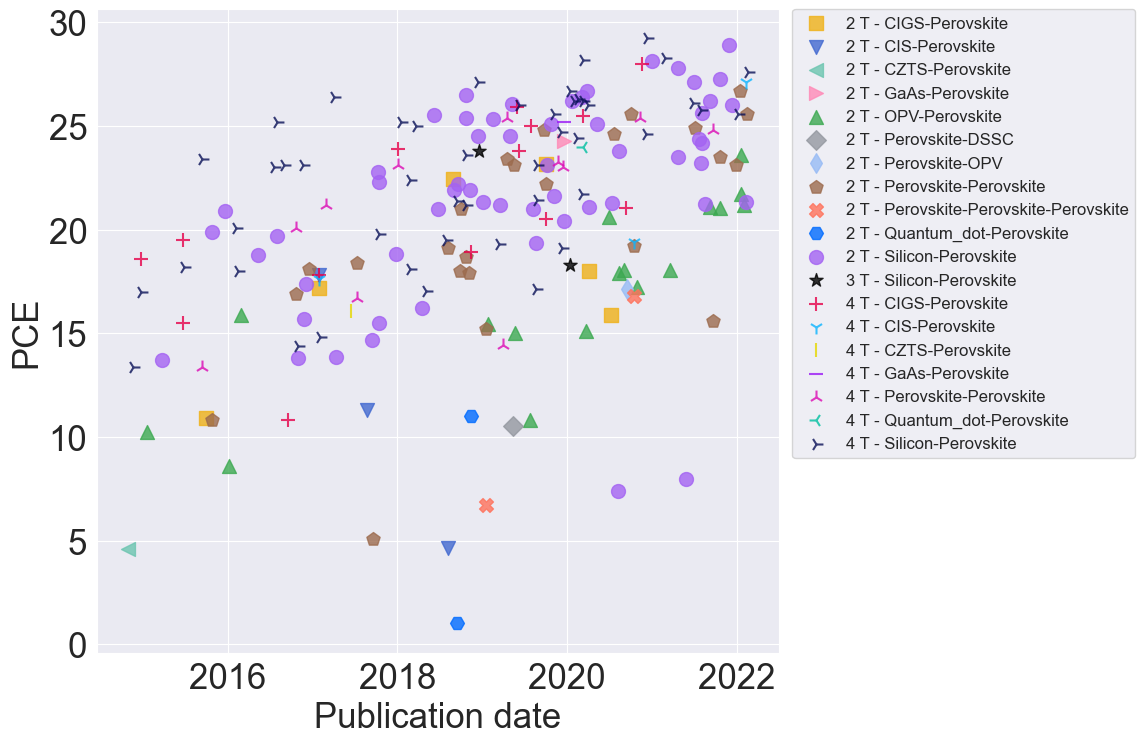

In [ ]:
celltype = np.sort(list(set(best_cells["celltype"].values)))
# Marker types and colors based on the category 'celltype'
marker_types = ['s', "v", "<", ">", "^", "D", "d", "p", "X", "H", 'o',
                "*",
                "+", "1", "|", "_", "2", "3", "4", "x"]  

colors = ["#efb118", "#4269d0", "#6cc5b0",   "#ff8ab7",   "#3ca951",  "#9498a0", "#97bbf5", "#9c6b4e",  "#ff725c",        "#006BFF", "#a463f2",
          "black",
          "#e60049", "#0bb4ff", "#e6d800", "#9b19f5", "#dc0ab4", "#00bfa0", "#091057"]

# Map each unique celltype to a marker and color
tech_to_marker = dict(zip(celltype, marker_types))
tech_to_color = dict(zip(celltype, colors))

# Apply a default theme
sns.set_style("darkgrid")
# Changing the font size for all elements in the plot
plt.rcParams.update({'font.size': 25})
# Set up a figure
fig, ax = plt.subplots(figsize=(12, 8), tight_layout=True)

# Iterate over the unique celltype and plot each separately with its own marker and color
for tech in celltype:
    # Filter the DataFrame for the current technology
    tech_data = best_cells[best_cells['celltype'] == tech]
    
    # Plot each technology with a specific marker and color
    ax.scatter(
        x=tech_data['publication_date'],
        y=tech_data['data.key_performance_metrics.power_conversion_efficiency'],
        label=tech,  # Add label for legend
        marker=tech_to_marker[tech],  # Use marker based on the 'Technology'
        color=tech_to_color[tech],  # Use color based on the 'Technology'
        s=100,  # Marker size
        alpha=0.8
    )
    
# Layout adjustments
ax.set_ylabel("PCE")
ax.set_xlabel("Publication date")
ax.xaxis.set_major_locator(mdates.YearLocator(2)) 
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=12)

# plt.savefig('figure_5_v1.pdf', dpi=600, bbox_inches='tight')

### Plot PCE vs the combined band gap

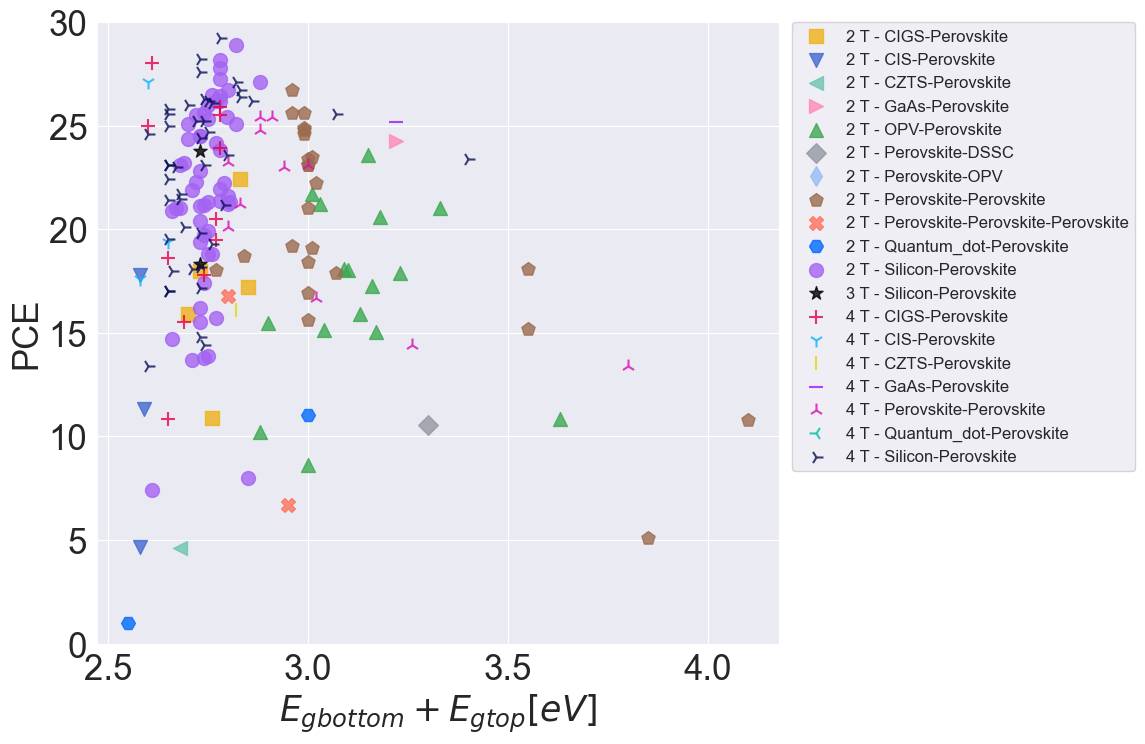

In [ ]:
# Apply a default theme
sns.set_style("darkgrid")
# Changing the font size for all elements in the plot
plt.rcParams.update({'font.size': 25})
# Set up a figure
fig, ax = plt.subplots(figsize=(12, 8), tight_layout=True)

# Iterate over the unique celltypes and plot each separately with its own marker and color
for tech in celltype:
    # Filter the DataFrame for the current celltype
    tech_data = best_cells[best_cells['celltype'] == tech]
    
    # Plot each technology with a specific marker and color
    ax.scatter(
        x=tech_data['Eg_tot'],
        y=tech_data['data.key_performance_metrics.power_conversion_efficiency'],
        label=tech,  # Add label for legend
        marker=tech_to_marker[tech],  # Use marker based on the 'Technology'
        color=tech_to_color[tech],  # Use color based on the 'Technology'
        s=100,  # Marker size
        alpha=0.8
    )
    
# Layout adjustments
ax.set_ylabel("PCE")
ax.set_ylim([0, 30])
ax.set_xlabel("$E_{g bottom} + E_{g top} [eV]$")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=12)

# plt.savefig('figure_5_b_v1.pdf', dpi=600, bbox_inches='tight')

### Exploration of the diversity in the stack architecture

In [168]:
# Remove 3-junction cells
devices = best_cells[best_cells["data.general.number_of_junctions"]==2]

# Groups of layers
layer_1 = []    # Bottom layers
layer_2 = []    # First photoabsorber
layer_3 = []    # Interconnecting layers
layer_4 = []    # Second photoabsorber
layer_5 = []    # Top layers

# Extract the information for the stack sequences
devices = devices["data.device_stack"].values

# List layer functionalities and materials and group them according to their position in the stack (bottom, first photoabsorber, interconnecting layers, second photoabsorber, top layers)
for device in devices:
    functionalities = []
    materials = []
    for layer in device:
        functionalities.append(layer.get("functionality"))
        materials.append(layer.get("name"))
        
    # Group layers based on their functionality
    photoabsorber_count = 0
    stack_1 = []    # Bottom layers
    stack_2 = []    # First photoabsorber
    stack_3 = []    # Interconnecting layers
    stack_4 = []    # Second photoabsorber
    stack_5 = []    # Top layers

    for mat, func in zip(materials, functionalities):
        if func == "photoabsorber":
            photoabsorber_count += 1
            if photoabsorber_count == 1:
                stack_2.append(mat)
            else:
                stack_4.append(mat)
        elif photoabsorber_count == 0:
            stack_1.append(mat)
        elif photoabsorber_count == 1:
            stack_3.append(mat)
        else:
            stack_5.append(mat)

    layer_1.append(" | ".join(stack_1))
    layer_2.append(" | ".join(stack_2))
    layer_3.append(" | ".join(stack_3))
    layer_4.append(" | ".join(stack_4))
    layer_5.append(" | ".join(stack_5))

# Sankey diagrams are cyclic graphs which means that we need to have uniq names for photoabsorbers in the first and second position. We can achieve this by adding a suffix to the photoabsorber materials based on their position in the stack.
layer_2 = [mat + "_b" for mat in layer_2]
layer_4 = [mat + "_t" for mat in layer_4] 

# For layer_1 and 5 replace empty strings with "Unspecified" to avoid issues with the sankey diagram
layer_1 = [mat if mat != "" else "Unspecified_1" for mat in layer_1]
layer_5 = [mat if mat != "" else "Unspecified_5" for mat in layer_5]

#For layer 4, repalce missing instances with perovskite
layer_4 = ["Perovskite_t" if mat == "_t" else mat for mat in layer_4]


# Create a dataframe with the layer information
layer_df = pd.DataFrame({
    "Bottom layers": layer_1,
    "Photoabsorber 1": layer_2,
    "Interconnecting layers": layer_3,
    "Photoabsorber 2": layer_4,
    "Top layers": layer_5
})

# Sort out most common layers and rename other layers to "Other" for better visualization in the sankey diagram
def rename_rare_layers(column, top_n=5, name="Other"):
    top_layers = column.value_counts().nlargest(top_n).index
    return column.apply(lambda x: x if x in top_layers else name)

layer_df["Bottom layers"] = rename_rare_layers(layer_df["Bottom layers"], top_n=sum(layer_df["Bottom layers"].value_counts()>2), name="Other_1")
# layer_df["Photoabsorber 1"] = rename_rare_layers(layer_df["Photoabsorber 1"], top_n=sum(layer_df["Photoabsorber 1"].value_counts()>2), name="Other_2")
layer_df["Interconnecting layers"] = rename_rare_layers(layer_df["Interconnecting layers"], top_n=sum(layer_df["Interconnecting layers"].value_counts()>2), name="Other_3")
# layer_df["Photoabsorber 2"] = rename_rare_layers(layer_df["Photoabsorber 2"], top_n=sum(layer_df["Photoabsorber 2"].value_counts()>2), name="Other_4")
layer_df["Top layers"] = rename_rare_layers(layer_df["Top layers"], top_n=sum(layer_df["Top layers"].value_counts()>2), name="Other_5")

# Define source and target and count the number of occurrences of each connection for the sankey diagram
sankey_df = pd.DataFrame(columns=["source", "target", "value"])
for i in range(len(layer_df.columns)-1):
    source_col = layer_df.columns[i]
    target_col = layer_df.columns[i+1]
    connections = layer_df.groupby([source_col, target_col]).size().reset_index(name="count")
    connections.columns = ["source", "target", "value"]
    sankey_df = pd.concat([sankey_df, connections], ignore_index=True)

In [170]:
sankey_df

,source,target,value
0,Ag,silicon_b,4
1,Ag | AZO,silicon_b,10
2,Ag | BCP | C60,Perovskite_b,10
3,Ag | BCP | C60 | PCBM-60,Perovskite_b,3
4,Ag | ITO,silicon_b,32
...,...,...,...
57,Perovskite_t,Spiro-MeOTAD | MoOx | ITO | Au-grid,4
58,Perovskite_t,TiO2-c | FTO | SLG,5
59,Perovskite_t,TiO2-mp | TiO2-c | FTO | SLG,16
60,Perovskite_t,TiO2-mp | TiO2-c | ITO | SLG,5


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
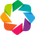

:Sankey   [source,target]   (value)

In [185]:
hv.extension('bokeh')

# Plot data
def hook(plot, element):
    plot.handles['text_1_glyph'].text_font = 'arial'
    plot.handles['text_1_glyph'].text_font_size = '18pt'
    # plot.handles['text_2_glyph'].text_font = 'arial'
    # plot.handles['text_2_glyph'].text_font_size = '16pt'

sankey2 = hv.Sankey(sankey_df, kdims=["source", "target"], vdims=["value"])
sankey2.opts(cmap='Colorblind',label_position='left',
                                 edge_color='source', edge_line_width=0,
                                 node_alpha=1.0, node_width=40, node_sort=True,
                                 width=2600, height=600, bgcolor="white",
                                 fontsize={'labels': 4},
                                 fontscale=1,
                                 show_values=False,
                                 hooks=[hook])